In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

General QC metrics for sequencing libraries for 96 standard and the matched 96 depleted RNA-seq 
-

In [16]:
#these are the standard output QC metric summaries 
data = pd.read_csv("applied_depletion_gregor_n100/192_WM_D_NYGC_output_report.csv")
data['depletion'] = np.where(data['sample'].str.contains('WM'), 'control', 'depleted')
data['depletion'] = pd.Categorical(data['depletion'], categories=['control', 'depleted'], ordered=True)
data

,sample,reads_raw,pct_adapter_detected,pct_trimmed,pct_trimmed_bases,reads,pct_GC,pct_dup_sequence,pct_rRNA,pct_globin,...,pct_chrM,pct_chrAuto,pct_contig,pct_coding,pct_utr,pct_intronic,pct_intergenic,pct_mrna,median_5_3_bias,depletion
0,3-4-WM,140683397.0,5.75,0.281,0.822,140288544.0,47.0,49.572,1.34,0.00,...,0.675,96.092,0.537,21.840,22.702,51.211,4.247,44.542,1.016,control
1,1-5-WM,123150325.0,5.90,0.378,0.958,122685124.0,45.5,48.557,0.46,0.01,...,0.592,96.509,0.218,23.049,21.723,51.550,3.679,44.772,0.944,control
2,8-7-D,140979636.0,3.15,0.012,0.124,140963044.0,42.5,46.170,0.18,0.00,...,0.002,97.254,0.141,17.767,14.091,63.612,4.530,31.858,0.827,depleted
3,3-2-WM,127821324.0,5.95,0.283,0.866,127459734.0,46.5,49.047,0.75,0.01,...,0.699,96.357,0.296,24.193,22.699,48.675,4.433,46.892,1.028,control
4,1-3-D,135249185.0,3.00,0.013,0.108,135232259.0,42.5,48.397,0.12,0.00,...,0.003,97.254,0.157,21.834,16.741,57.076,4.349,38.575,0.885,depleted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,5-1-D,130315737.0,3.00,0.012,0.113,130299476.0,44.0,46.640,0.23,0.00,...,0.005,97.194,0.205,18.135,13.942,63.360,4.563,32.077,0.951,depleted
188,7-6-WM,121078858.0,5.50,0.309,0.830,120704722.0,45.5,47.198,0.46,0.00,...,0.421,96.634,0.227,21.290,19.916,54.953,3.841,41.206,0.946,control
189,4-4-D,142454431.0,3.05,0.011,0.115,142438151.0,43.0,47.434,0.25,0.00,...,0.005,97.100,0.211,18.630,14.335,62.701,4.335,32.965,0.979,depleted
190,10-4-WM,128104190.0,6.25,0.312,0.957,127703937.0,46.5,51.648,0.64,0.00,...,0.475,96.799,0.268,24.426,24.438,47.201,3.934,48.864,1.010,control


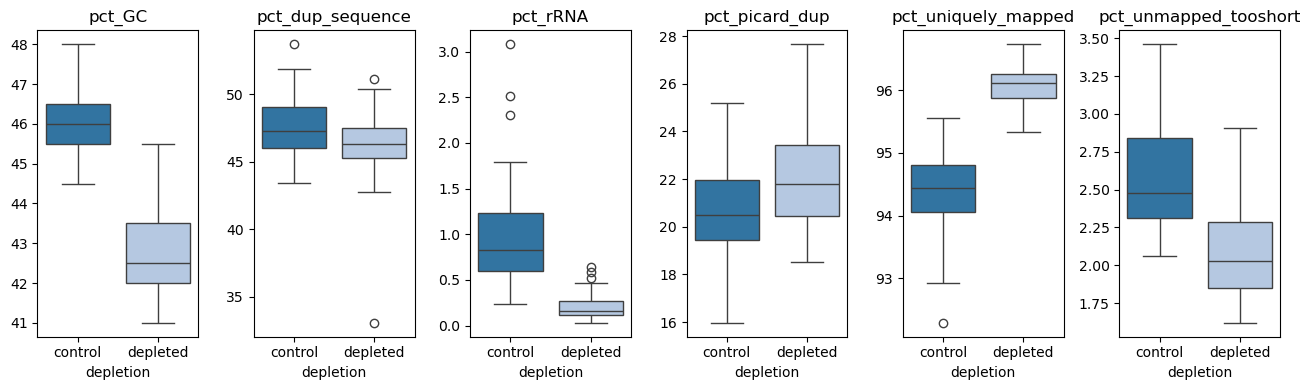

In [17]:
#check general pct metrics and compare betweeen groups 
general_pcts = ['pct_GC', 'pct_dup_sequence', 'pct_rRNA', 'pct_picard_dup', 'pct_uniquely_mapped', 'pct_unmapped_tooshort', 'depletion']
sub = data[data.columns.intersection(general_pcts)]

plotted_columns = general_pcts[:-1]
plt.figure(figsize=(13, 4))

for i, column in enumerate(plotted_columns):
    plt.subplot(1, 6, i+1)
    sns.boxplot(
        x='depletion',
        y=column,
        hue='depletion',  
        data=sub,
        palette='tab20'    
    )
    plt.ylabel('')
    plt.title(column)
    plt.legend([],[], frameon=False)  

plt.tight_layout()
plt.savefig('applied_depletion_gregor_n100/figures/QC_results_p1.png', dpi=300)

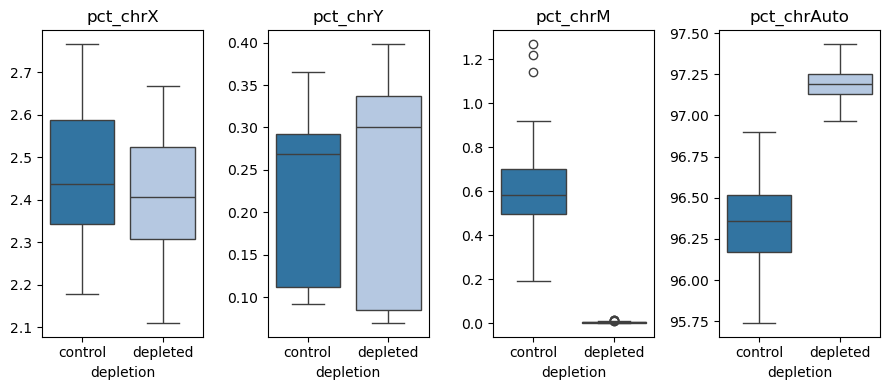

In [18]:
#check mapping to different chromosomes
general_pcts = ['pct_chrX', 'pct_chrY', 'pct_chrM', 'pct_chrAuto', 'depletion']
sub = data[data.columns.intersection(general_pcts)]

plotted_columns = general_pcts[:-1]
plt.figure(figsize=(9, 4))

for i, column in enumerate(plotted_columns):
    plt.subplot(1, 4, i+1)
    sns.boxplot(
        x='depletion',
        y=column,
        hue='depletion',  
        data=sub,
        palette='tab20'    
    )
    plt.ylabel('')
    plt.title(column)
    plt.legend([],[], frameon=False)  

plt.tight_layout()
plt.savefig('applied_depletion_gregor_n100/figures/QC_results_p2.png', dpi=300)

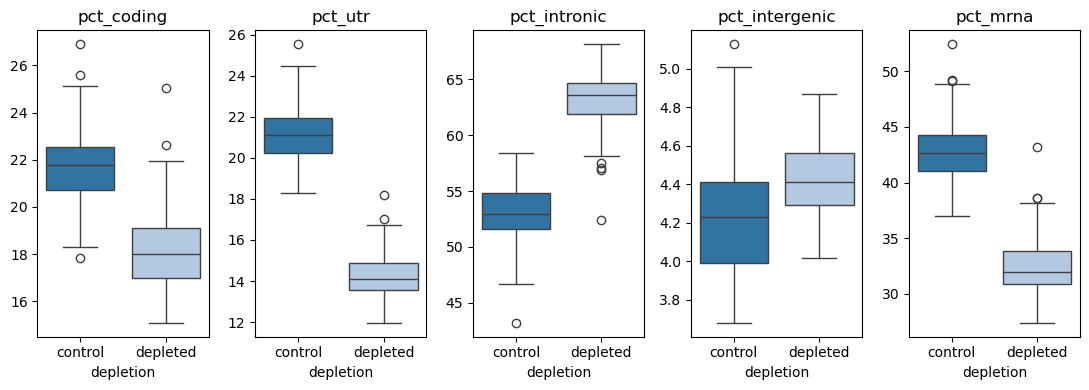

In [19]:
general_pcts = ['pct_coding', 'pct_utr', 'pct_intronic', 'pct_intergenic', 'pct_mrna', 'depletion']
sub = data[data.columns.intersection(general_pcts)]

plotted_columns = general_pcts[:-1]
plt.figure(figsize=(11, 4))

for i, column in enumerate(plotted_columns):
    plt.subplot(1, 5, i+1)
    sns.boxplot(
        x='depletion',
        y=column,
        hue='depletion', 
        data=sub,
        palette='tab20'    
    )
    plt.ylabel('')
    plt.title(column)
    plt.legend([],[], frameon=False)  

plt.tight_layout()
plt.savefig('applied_depletion_gregor_n100/figures/QC_results_p3.png', dpi=300)